In [38]:
# Importing reqiured libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Importing warnings
import warnings
warnings.filterwarnings('ignore')

In [39]:
# Loading sample data
data = pd.read_csv('Cust_Spend_Data.csv')
data.head()

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3


In [40]:
# Data shape
data.shape

(10, 7)

In [41]:
# Data with and without PII (Personally Identifiable Information)
pdata = data.iloc[:, 2:] # Data without index 1 and 2
idata = data.iloc[:, :2] # Data with index 1 and 2

In [42]:
# Data Scaling
scale = StandardScaler()  # StandardScaler standardizes features by removing the mean and scaling to unit variance

scaled_data = scale.fit_transform(pdata)  # fit_transform() learns mean & std from pdata (fit) then applies scaling (transform) → result is a NumPy array

# Data After Scaling
scaled_df = pd.DataFrame(
    scaled_data, 
    columns=scale.get_feature_names_out()  # get_feature_names_out() retrieves original column names after scaling
)

scaled_df  # display the scaled dataframe

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1.886498,-1.240347,1.527525,-0.741433,-1.380131
1,0.787567,-0.620174,-0.654654,1.280656,1.725164
2,0.787567,1.860521,1.527525,-0.292080,0.000000
3,0.604412,0.620174,1.527525,-0.741433,0.000000
4,0.421257,1.240347,-0.654654,1.730009,-0.345033
5,-0.311364,-0.620174,-0.654654,-0.741433,1.380131
6,-0.860829,0.620174,-0.654654,1.505333,-0.690066
7,-0.860829,-0.620174,-0.654654,-0.741433,-1.035098
8,-1.043984,-1.240347,-0.654654,-0.516756,-0.690066
9,-1.410294,0.000000,-0.654654,-0.741433,1.035098


In [43]:
# Algo with Random Clusters
r_kmeans = KMeans(
    n_clusters=5,       # number of clusters to form
    init='random',      # initialize centroids randomly
    n_init='auto',      # number of times KMeans will run with different centroid seeds
    random_state=42     # ensures reproducibility of random initialization
)

rkmeans = r_kmeans.fit_predict(scaled_df)  # fit_predict() fits the model on scaled_df and returns the cluster each sample belongs to

rkmeans += 1  # cluster labels start from 0 by default, adding 1 makes them start from 1 (more human-friendly)

# DataFrame for the Predicted Cluster Labels
r_cluster = pd.DataFrame(rkmeans, columns=['r_cluster'])  # wrap cluster labels into a DataFrame for easy merging

# Concat the Cluster Labels with the Raw Data
pdata['r_cluster'] = r_cluster 

# Data Sample
pdata  

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,r_cluster
0,10000,2,1,1,0,1
1,7000,3,0,10,9,4
2,7000,7,1,3,4,5
3,6500,5,1,1,4,5
4,6000,6,0,12,3,3
5,4000,3,0,1,8,4
6,2500,5,0,11,2,3
7,2500,3,0,1,1,2
8,2000,2,0,2,2,2
9,1000,4,0,1,7,2


In [44]:
# Optimum number of clusters
wcss = [] # within cluster sum of squared errors


for cluster in range(1,11):
    kmeans = KMeans(n_clusters = cluster, init = 'k-means++', n_init = 'auto', random_state = 42) #k-means++ smart centroid initialization to speed up convergence
    kmeans = kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

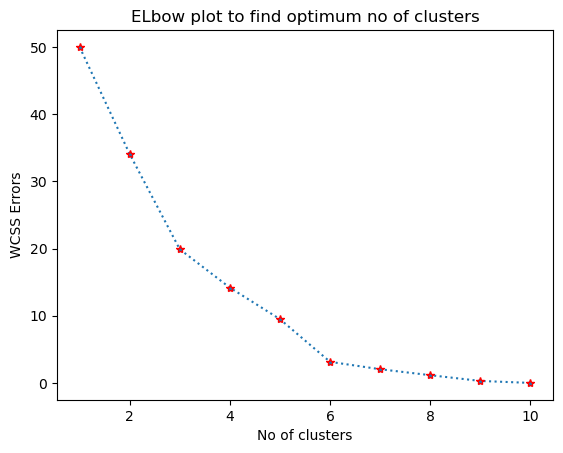

In [45]:
# Elbow plot
plt.plot(range(1,11), wcss, ls = ':', marker = '*', markeredgecolor = 'r')
plt.title('ELbow plot to find optimum no of clusters')
plt.xlabel('No of clusters')
plt.ylabel('WCSS Errors')
plt.show()

In [46]:
# Final model with optimum centroids
final_kmeans_model = KMeans(
    n_clusters=3,    
    init='k-means++',  
    n_init='auto',  
    random_state=42   
)

final_cluster_labels = final_kmeans_model.fit_predict(scaled_df)  # fit model on scaled dataframe and get cluster labels for each row(data points)

final_cluster_labels += 1  # shift labels to start from 1 for easier readability

# DataFrame for the predicted clusters
final_clusters_df = pd.DataFrame(final_cluster_labels, columns=['final_cluster'])  # wrap predicted cluster labels into a DataFrame with a clear column name

# Concat the cluster with the raw data
pdata['final_cluster'] = final_clusters_df 

# Data Sample
pdata  

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,r_cluster,final_cluster
0,10000,2,1,1,0,1,1
1,7000,3,0,10,9,4,3
2,7000,7,1,3,4,5,1
3,6500,5,1,1,4,5,1
4,6000,6,0,12,3,3,3
5,4000,3,0,1,8,4,2
6,2500,5,0,11,2,3,3
7,2500,3,0,1,1,2,2
8,2000,2,0,2,2,2,2
9,1000,4,0,1,7,2,2


In [47]:
# Dropping random clusters from pdata to get cleaned optimum columns
pdata.drop(['r_cluster'], axis = 1, inplace = True)

In [48]:
# Data Sample after prediction
pdata

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,final_cluster
0,10000,2,1,1,0,1
1,7000,3,0,10,9,3
2,7000,7,1,3,4,1
3,6500,5,1,1,4,1
4,6000,6,0,12,3,3
5,4000,3,0,1,8,2
6,2500,5,0,11,2,3
7,2500,3,0,1,1,2
8,2000,2,0,2,2,2
9,1000,4,0,1,7,2


In [49]:
# Cluster mapping
cluster_map = {1 : 'Gold', 2 : 'Bronze', 3 : 'Silver'}

# Mapping the columns to the dataframe
pdata['cust_class'] = pdata['final_cluster'].map(cluster_map)

# Append the PII data
cust_class_df = pd.concat([idata, pdata], axis = 1)
cust_class_df

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,final_cluster,cust_class
0,1,A,10000,2,1,1,0,1,Gold
1,2,B,7000,3,0,10,9,3,Silver
2,3,C,7000,7,1,3,4,1,Gold
3,4,D,6500,5,1,1,4,1,Gold
4,5,E,6000,6,0,12,3,3,Silver
5,6,F,4000,3,0,1,8,2,Bronze
6,7,G,2500,5,0,11,2,3,Silver
7,8,H,2500,3,0,1,1,2,Bronze
8,9,I,2000,2,0,2,2,2,Bronze
9,10,J,1000,4,0,1,7,2,Bronze


In [50]:
# Mean values of each data columns based on the clusters
cluster_mean = pd.DataFrame(round(pdata.groupby('cust_class').mean(),2))
cluster_mean

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,final_cluster
cust_class,,,,,,
Bronze,2375.00,3.00,0.0,1.25,4.50,2.0
Gold,7833.33,4.67,1.0,1.67,2.67,1.0
Silver,5166.67,4.67,0.0,11.00,4.67,3.0


In [51]:
# Cluster prediction of new data - single row

# Input data
new_data = {'Avg_Mthly_Spend': 9000,
            'No_Of_Visits': 5,
            'Apparel_Items': 2,
            'FnV_Items': 7,
            'Staples_Items': 6}

# Create dataframe for incoming single row of data
new_df = pd.DataFrame([new_data])


# Prepare the data for ML model prediction
# Scale the data
new_data_scaled = scale.transform(new_df)
new_data_scaled = pd.DataFrame(new_data_scaled, columns=scale.get_feature_names_out())

# Model prediction
data_pred = final_kmeans_model.predict(new_data_scaled)
data_pred += 1

# Customer - cluster mapping
if data_pred[0] == 1:
    print('The customer belongs to gold class.')
elif data_pred[0] == 2:
    print('The customer belongs to bronze class.')
else:
    print('The customer belongs to silver class.')

The customer belongs to gold class.


In [52]:
# Cluster prediction of new data - multiple row

# Input data
new_multi_data = {'Avg_Mthly_Spend': [2000, 6000, 3000],
                'No_Of_Visits': [5, 6, 1],
                'Apparel_Items': [1, 0, 1],
                'FnV_Items': [7, 1, 4],
                'Staples_Items': [6, 0, 1]}

# Create a dataframe for the above data
new_multi_df = pd.DataFrame(new_multi_data)

# Prepare the data for ML model prediction
# scale the data
n_data_scaled = scale.transform(new_multi_df)
n_data_scaled = pd.DataFrame(n_data_scaled, columns=scale.get_feature_names_out())

# Model prediction
n_data_pred = final_kmeans_model.predict(n_data_scaled)
n_data_pred += 1
new_multi_df['final_cluster'] = n_data_pred

# Mapping
new_multi_df['final_cluster'] = new_multi_df['final_cluster'].map(cluster_map)
new_multi_df

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,final_cluster
0,2000,5,1,7,6,Silver
1,6000,6,0,1,0,Gold
2,3000,1,1,4,1,Bronze
